In [1]:
from datetime import datetime, timedelta
import csv
import sqlite3
import requests
from bs4 import BeautifulSoup
import json
from typing import Dict, List
import re

In [2]:
import numpy as np
import seaborn as sns
import matplotlib as mpl
import plotly.express as px
import nbformat
import plotly.graph_objects as go

In [3]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [4]:
world = gpd.read_file("ne_110m_admin_1_states_provinces/ne_110m_admin_1_states_provinces.shp")

# Show the first few rows
print(world.head())

           featurecla  scalerank adm1_code  diss_me iso_3166_2  \
0  Admin-1 scale rank          2  USA-3514     3514      US-MN   
1  Admin-1 scale rank          2  USA-3515     3515      US-MT   
2  Admin-1 scale rank          2  USA-3516     3516      US-ND   
3  Admin-1 scale rank          2  USA-3517     3517      US-HI   
4  Admin-1 scale rank          2  USA-3518     3518      US-ID   

                                   wikipedia iso_a2  adm0_sr          name  \
0     http://en.wikipedia.org/wiki/Minnesota     US        1     Minnesota   
1       http://en.wikipedia.org/wiki/Montana     US        1       Montana   
2  http://en.wikipedia.org/wiki/North_Dakota     US        1  North Dakota   
3        http://en.wikipedia.org/wiki/Hawaii     US        8        Hawaii   
4         http://en.wikipedia.org/wiki/Idaho     US        1         Idaho   

    name_alt  ... FCLASS_ID FCLASS_PL FCLASS_GR FCLASS_IT FCLASS_NL FCLASS_SE  \
0   MN|Minn.  ...      None      None      None      

In [5]:
world = world.rename(columns={'iso_3166_2': 'state'})

In [6]:
world.head()

,featurecla,scalerank,adm1_code,diss_me,state,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry
0,Admin-1 scale rank,2,USA-3514,3514,US-MN,http://en.wikipedia.org/wiki/Minnesota,US,1,Minnesota,MN|Minn.,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-89.95766 47.28691, -90.13175 47.292..."
1,Admin-1 scale rank,2,USA-3515,3515,US-MT,http://en.wikipedia.org/wiki/Montana,US,1,Montana,MT|Mont.,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-116.04823 49.00037, -113.0595 49.00..."
2,Admin-1 scale rank,2,USA-3516,3516,US-ND,http://en.wikipedia.org/wiki/North_Dakota,US,1,North Dakota,ND|N.D.,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-97.22894 49.00089, -97.21414 48.902..."
3,Admin-1 scale rank,2,USA-3517,3517,US-HI,http://en.wikipedia.org/wiki/Hawaii,US,8,Hawaii,HI|Hawaii,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-155.93665 19.05939, -155.9080..."
4,Admin-1 scale rank,2,USA-3518,3518,US-ID,http://en.wikipedia.org/wiki/Idaho,US,1,Idaho,ID|Idaho,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-116.04823 49.00037, -115.9678 47.95..."


In [7]:
world['state'].unique()

array(['US-MN', 'US-MT', 'US-ND', 'US-HI', 'US-ID', 'US-WA', 'US-AZ',
       'US-CA', 'US-CO', 'US-NV', 'US-NM', 'US-OR', 'US-UT', 'US-WY',
       'US-AR', 'US-IA', 'US-KS', 'US-MO', 'US-NE', 'US-OK', 'US-SD',
       'US-LA', 'US-TX', 'US-CT', 'US-MA', 'US-NH', 'US-RI', 'US-VT',
       'US-AL', 'US-FL', 'US-GA', 'US-MS', 'US-SC', 'US-IL', 'US-IN',
       'US-KY', 'US-NC', 'US-OH', 'US-TN', 'US-VA', 'US-WI', 'US-WV',
       'US-DE', 'US-DC', 'US-MD', 'US-NJ', 'US-NY', 'US-PA', 'US-ME',
       'US-MI', 'US-AK'], dtype=object)

In [8]:
world['state'].head()

0    US-MN
1    US-MT
2    US-ND
3    US-HI
4    US-ID
Name: state, dtype: object

In [9]:
world.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 51 entries, 0 to 50
Columns: 122 entries, featurecla to geometry
dtypes: float64(4), geometry(1), int32(20), int64(1), object(96)
memory usage: 44.8+ KB


<Axes: >

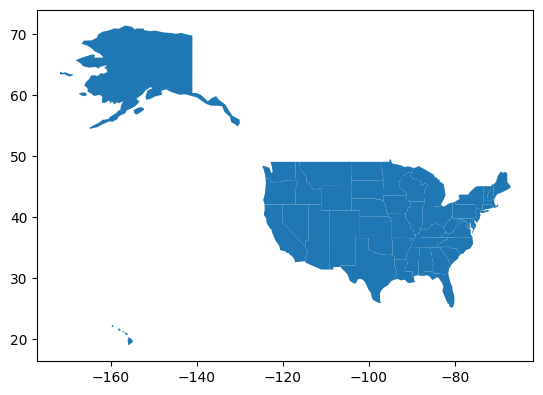

In [10]:
world.plot()

In [11]:
print(world.columns)

Index(['featurecla', 'scalerank', 'adm1_code', 'diss_me', 'state', 'wikipedia',
       'iso_a2', 'adm0_sr', 'name', 'name_alt',
       ...
       'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT', 'FCLASS_NL',
       'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'FCLASS_TLC', 'geometry'],
      dtype='object', length=122)


In [12]:
world.geometry.head()

0    POLYGON ((-89.95766 47.28691, -90.13175 47.292...
1    POLYGON ((-116.04823 49.00037, -113.0595 49.00...
2    POLYGON ((-97.22894 49.00089, -97.21414 48.902...
3    MULTIPOLYGON (((-155.93665 19.05939, -155.9080...
4    POLYGON ((-116.04823 49.00037, -115.9678 47.95...
Name: geometry, dtype: geometry

In [13]:
world.geometry.extract_unique_points()

0     MULTIPOINT ((-89.95766 47.28691), (-90.13175 4...
1     MULTIPOINT ((-116.04823 49.00037), (-113.0595 ...
2     MULTIPOINT ((-97.22894 49.00089), (-97.21414 4...
3     MULTIPOINT ((-155.93665 19.05939), (-155.90806...
4     MULTIPOINT ((-116.04823 49.00037), (-115.9678 ...
5     MULTIPOINT ((-117.03143 48.99931), (-117.02665...
6     MULTIPOINT ((-109.04522 36.99991), (-109.04367...
7     MULTIPOINT ((-114.64222 35.05311), (-114.62212...
8     MULTIPOINT ((-102.05017 40.00081), (-102.04012...
9     MULTIPOINT ((-117.02825 42.00002), (-114.03422...
10    MULTIPOINT ((-109.04367 31.3419), (-109.04522 ...
11    MULTIPOINT ((-116.915 45.99998), (-116.679 45....
12    MULTIPOINT ((-114.03422 41.99312), (-111.05024...
13    MULTIPOINT ((-111.08518 44.50615), (-111.06719...
14    MULTIPOINT ((-89.66292 36.02307), (-89.67351 3...
15    MULTIPOINT ((-96.45266 43.50179), (-95.35994 4...
16    MULTIPOINT ((-102.04118 36.99198), (-102.04012...
17    MULTIPOINT ((-89.66292 36.02307), (-90.315

In [14]:
# 3 is hawaii
world.name.iloc[10]

'New Mexico'

In [16]:
#iso_3166_2
world.state.iloc[10]

'US-NM'

<Axes: >

<Figure size 1000x800 with 0 Axes>

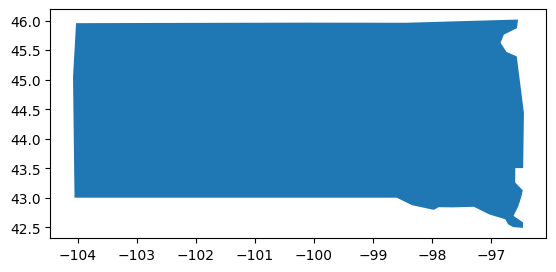

In [12]:
country_shape = world.geometry.iloc[20]
# Create a larger plot
plt.figure(figsize=(10, 8))  
# Plot the shape using a GeoSeries
gpd.GeoSeries([country_shape]).plot()

In [17]:
class DatabaseManager:
    def __init__(self, db_name = "Airline_delay.db"):
        self.conn = sqlite3.connect(db_name)
        self.cursor = self.conn.cursor()

    #def save_table(self, df, table_name):
    #    df.to_sql(table_name, self.conn, if_exists='replace', index=False)

    def query(self, sql_query):
        return pd.read_sql(sql_query, self.conn)
    
    def add_column(self, table_name, column_name, data_type):
        self.cursor.execute(f"""
        ALTER TABLE {table_name}
        ADD COLUMN {column_name} {data_type};
        """)
        self.conn.commit()
    
    def execute2(self, sql_query):
        self.cursor.execute(sql_query)
        self.conn.commit()

    def execute(self, sql_query, params=None):
        if params:
            self.cursor.execute(sql_query, params)
        else:
            self.cursor.execute(sql_query)
        self.conn.commit()

    def close(self):
        self.conn.close()

In [18]:
#connect to DB
conn = sqlite3.connect("Airline_delay.db")
df = pd.read_sql("SELECT * FROM delays", conn)

In [19]:
db = DatabaseManager()

In [20]:
from shapely.geometry import Point

In [21]:
delay = pd.read_csv("Delay_2018_2019.csv") 
delay2 = pd.read_csv("Delay_2020_2021.csv") 
delay3 = pd.read_csv("Delay_2022_2023.csv") 
delay4 = pd.read_csv("Delay_2024.csv") 

In [22]:
delay_all = pd.concat([delay, delay2, delay3, delay4], ignore_index=True)

In [23]:
delay_all.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2019,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",53.0,6.0,3.05,0.22,...,0.00,2.52,0.0,0.0,265.0,110.0,10.0,6.0,0.0,139.0
1,2019,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",115.0,4.0,0.03,0.00,...,0.00,2.62,0.0,2.0,157.0,1.0,0.0,40.0,0.0,116.0
2,2019,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",191.0,13.0,7.49,2.31,...,0.00,1.73,0.0,1.0,678.0,332.0,153.0,82.0,0.0,111.0
3,2019,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",6.0,1.0,0.00,0.00,...,0.00,0.00,0.0,0.0,19.0,0.0,0.0,19.0,0.0,0.0
4,2019,12,9E,Endeavor Air Inc.,ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",3804.0,470.0,116.84,11.79,...,0.45,192.07,3.0,0.0,32926.0,11584.0,608.0,4885.0,93.0,15756.0


In [24]:
delay_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148862 entries, 0 to 148861
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 148862 non-null  int64  
 1   month                148862 non-null  int64  
 2   carrier              148862 non-null  object 
 3   carrier_name         148862 non-null  object 
 4   airport              148862 non-null  object 
 5   airport_name         148862 non-null  object 
 6   arr_flights          148597 non-null  float64
 7   arr_del15            148383 non-null  float64
 8   carrier_ct           148597 non-null  float64
 9   weather_ct           148597 non-null  float64
 10  nas_ct               148597 non-null  float64
 11  security_ct          148597 non-null  float64
 12  late_aircraft_ct     148597 non-null  float64
 13  arr_cancelled        148597 non-null  float64
 14  arr_diverted         148597 non-null  float64
 15  arr_delay        

In [25]:
delay_all.dropna(inplace=True)

In [26]:
delay_all.isnull().sum()

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

In [27]:
delay_all['airport_name'].head().unique()

array(['Allentown/Bethlehem/Easton, PA: Lehigh Valley International',
       'Alexandria, LA: Alexandria International',
       'Augusta, GA: Augusta Regional at Bush Field',
       'Albany, NY: Albany International',
       'Atlanta, GA: Hartsfield-Jackson Atlanta International'],
      dtype=object)

In [29]:
delay_all['state'] = delay_all['airport_name'].str.extract(r',\s*([A-Z]{2}):')

In [31]:
delay_all['state'].head().unique()

array(['PA', 'LA', 'GA', 'NY'], dtype=object)

In [32]:
delay_all['state'] = 'US-' + delay_all['state']

In [33]:
#create array with us states

us_states= ['US-MN', 'US-MT', 'US-ND', 'US-HI', 'US-ID', 'US-WA', 'US-AZ',
       'US-CA', 'US-CO', 'US-NV', 'US-NM', 'US-OR', 'US-UT', 'US-WY',
       'US-AR', 'US-IA', 'US-KS', 'US-MO', 'US-NE', 'US-OK', 'US-SD',
       'US-LA', 'US-TX', 'US-CT', 'US-MA', 'US-NH', 'US-RI', 'US-VT',
       'US-AL', 'US-FL', 'US-GA', 'US-MS', 'US-SC', 'US-IL', 'US-IN',
       'US-KY', 'US-NC', 'US-OH', 'US-TN', 'US-VA', 'US-WI', 'US-WV',
       'US-DE', 'US-DC', 'US-MD', 'US-NJ', 'US-NY', 'US-PA', 'US-ME',
       'US-MI', 'US-AK']

In [34]:
delay_all_data = world[world['state'].isin(us_states)]

print(delay_all_data[['state']].head())

   state
0  US-MN
1  US-MT
2  US-ND
3  US-HI
4  US-ID


In [35]:
delay_all_data.head(2)

,featurecla,scalerank,adm1_code,diss_me,state,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry
0,Admin-1 scale rank,2,USA-3514,3514,US-MN,http://en.wikipedia.org/wiki/Minnesota,US,1,Minnesota,MN|Minn.,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-89.95766 47.28691, -90.13175 47.292..."
1,Admin-1 scale rank,2,USA-3515,3515,US-MT,http://en.wikipedia.org/wiki/Montana,US,1,Montana,MT|Mont.,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-116.04823 49.00037, -113.0595 49.00..."


In [36]:
state_2020 = delay_all[delay_all['year'].isin([2020, 2021])]
state_2020.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,state
44914,2021,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",127.0,9.0,2.51,0.00,...,2.95,0.0,0.0,264.0,119.0,0.0,68.0,0.0,77.0,US-PA
44915,2021,12,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",73.0,11.0,5.02,0.00,...,1.87,0.0,0.0,342.0,125.0,0.0,142.0,0.0,75.0,US-GA
44916,2021,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,8.0,2.63,0.00,...,1.15,0.0,0.0,439.0,156.0,0.0,103.0,0.0,180.0,US-LA
44917,2021,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",166.0,18.0,8.53,3.25,...,2.74,0.0,1.0,1266.0,291.0,693.0,167.0,0.0,115.0,US-GA
44918,2021,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",52.0,6.0,3.15,1.88,...,0.82,0.0,0.0,497.0,278.0,180.0,21.0,0.0,18.0,US-NY


In [37]:
state_2022 = delay_all[delay_all['year'].isin([2022, 2023, 2024])]
state_2022.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,state
85881,2023,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",72.0,5.0,2.46,1.00,...,0.81,0.0,0.0,672.0,61.0,574.0,20.0,0.0,17.0,US-PA
85882,2023,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,7.0,4.25,0.00,...,1.75,0.0,0.0,348.0,252.0,0.0,33.0,0.0,63.0,US-LA
85883,2023,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",95.0,10.0,5.94,0.00,...,3.00,0.0,0.0,859.0,536.0,0.0,47.0,0.0,276.0,US-GA
85884,2023,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",23.0,2.0,0.56,0.00,...,1.44,1.0,0.0,75.0,9.0,0.0,0.0,0.0,66.0,US-NY
85885,2023,12,9E,Endeavor Air Inc.,ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",2111.0,256.0,76.88,8.75,...,117.94,1.0,0.0,21424.0,8906.0,732.0,1487.0,0.0,10299.0,US-GA


In [60]:
joined_data = delay_all_data.merge(state_2022[['state', 'arr_delay', 'arr_del15', 'arr_cancelled', 'arr_flights' ]], on='state', how='left')

In [61]:
joined_data2020 = delay_all_data.merge(state_2020[['state', 'arr_delay', 'arr_del15', 'arr_cancelled', 'arr_flights' ]], on='state', how='left')

In [62]:
print(joined_data2020[['state', 'arr_delay', 'arr_del15', 'arr_cancelled', 'arr_flights', 'geometry']].head())

   state  arr_delay  arr_del15  arr_cancelled  arr_flights  \
0  US-MN      486.0        9.0            2.0         41.0   
1  US-MN    19442.0      210.0           28.0       1128.0   
2  US-MN      243.0        5.0            0.0         37.0   
3  US-MN     5222.0       56.0            4.0        311.0   
4  US-MN      172.0        3.0            6.0         31.0   

                                            geometry  
0  POLYGON ((-89.95766 47.28691, -90.13175 47.292...  
1  POLYGON ((-89.95766 47.28691, -90.13175 47.292...  
2  POLYGON ((-89.95766 47.28691, -90.13175 47.292...  
3  POLYGON ((-89.95766 47.28691, -90.13175 47.292...  
4  POLYGON ((-89.95766 47.28691, -90.13175 47.292...  


In [63]:
sorted_cancelled = joined_data[['state', 'arr_delay', 'arr_del15', 'arr_cancelled', 'arr_flights']].sort_values(by='arr_del15')

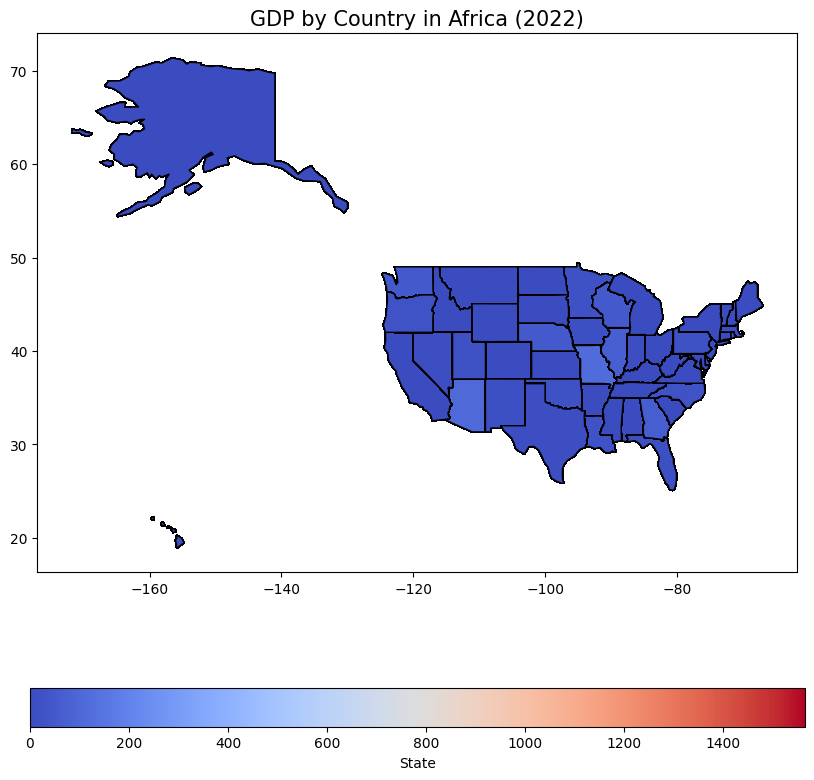

In [64]:
# Plot the map with GDP values
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot the geometry and color by GDP (USD)
joined_data.plot(column='arr_cancelled', ax=ax, legend=True,
                 legend_kwds={'label': "State",
                              'orientation': "horizontal"},
                 cmap='coolwarm', edgecolor='k')

# Add a title
ax.set_title('GDP by Country in Africa (2022)', fontsize=15)

# Show the plot
plt.show()

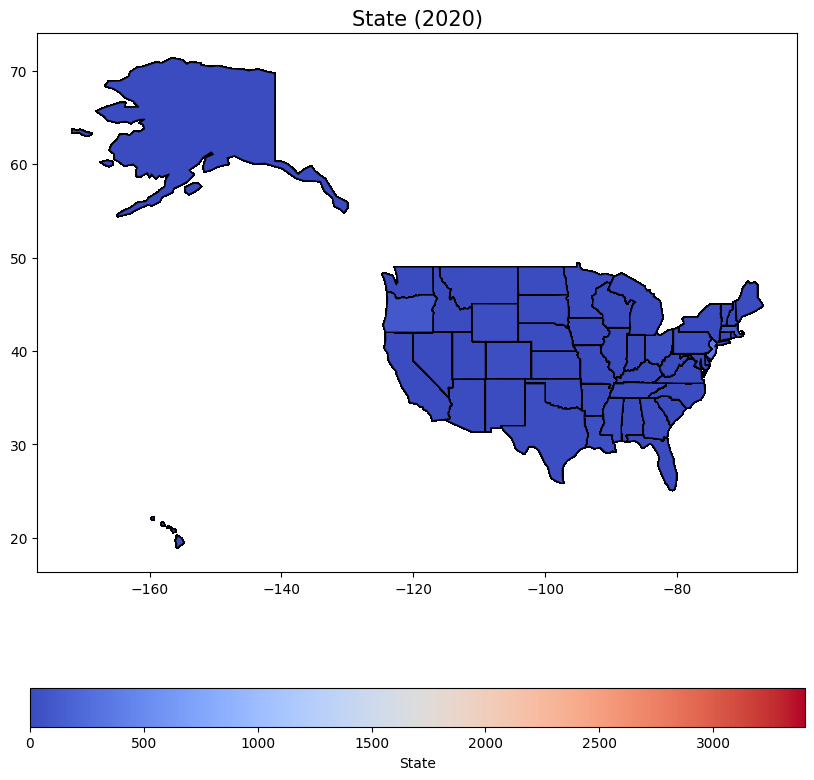

In [43]:
# Plot the map with GDP values
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot the geometry and color by GDP (USD)
joined_data2020.plot(column='arr_del15', ax=ax, legend=True,
                 legend_kwds={'label': "State",
                              'orientation': "horizontal"},
                 cmap='coolwarm', edgecolor='k')

# Add a title
ax.set_title('State (2020)', fontsize=15)

# Show the plot
plt.show()

In [46]:
print(joined_data2020['cancel_rate'].describe())

count    40169.000000
mean         0.040939
std          0.105555
min          0.000000
25%          0.000000
50%          0.000000
75%          0.028807
max          0.988095
Name: cancel_rate, dtype: float64


In [47]:
print(joined_data2020['arr_del15'].describe())

count    40169.000000
mean        35.825114
std        114.682578
min          0.000000
25%          3.000000
50%          8.000000
75%         23.000000
max       3402.000000
Name: arr_del15, dtype: float64


In [48]:
print(joined_data2020['arr_cancelled'].value_counts())

arr_cancelled
0.0       20504
1.0        5378
2.0        2912
3.0        1778
4.0        1252
          ...  
438.0         1
172.0         1
741.0         1
620.0         1
1107.0        1
Name: count, Length: 431, dtype: int64


In [49]:
joined_data2020.plot(
    column='cancel_rate',
    ax=ax,
    cmap='coolwarm',
    edgecolor='k',
    legend=True,
    scheme='quantiles',   # 👈 key fix
    k=2                   # number of classes
)
plt.show()

In [65]:
#df['arr_delay'] = df['arr_delay'] / df['arr_flights']
joined_data2020['arr_delay'] = (
    joined_data2020['arr_delay'] / joined_data2020['arr_flights']
)

In [45]:
joined_data2020['cancel_rate'] = (
    joined_data2020['arr_cancelled'] / joined_data2020['arr_flights']
)

In [66]:
joined_data2020['arr_delay'].describe()

count    40169.000000
mean         8.480607
std         10.730029
min          0.000000
25%          2.634884
50%          5.851852
75%         11.153652
max        712.000000
Name: arr_delay, dtype: float64

In [50]:
joined_data2020['cancel_rate'].describe()

count    40169.000000
mean         0.040939
std          0.105555
min          0.000000
25%          0.000000
50%          0.000000
75%          0.028807
max          0.988095
Name: cancel_rate, dtype: float64

In [51]:
joined_data2020['cancel_rate'].value_counts().head(10)

cancel_rate
0.000000    20504
0.032258      299
0.016129      203
0.033333      185
0.064516      138
0.016667      134
0.035714      110
0.034483      110
0.018868      104
0.066667      100
Name: count, dtype: int64

In [52]:
#option 1 fix
plot_df = joined_data2020[joined_data2020['cancel_rate'] > 0]

In [53]:
# 2 fix
joined_data2020['cancel_rate_log'] = np.log1p(joined_data2020['cancel_rate'])

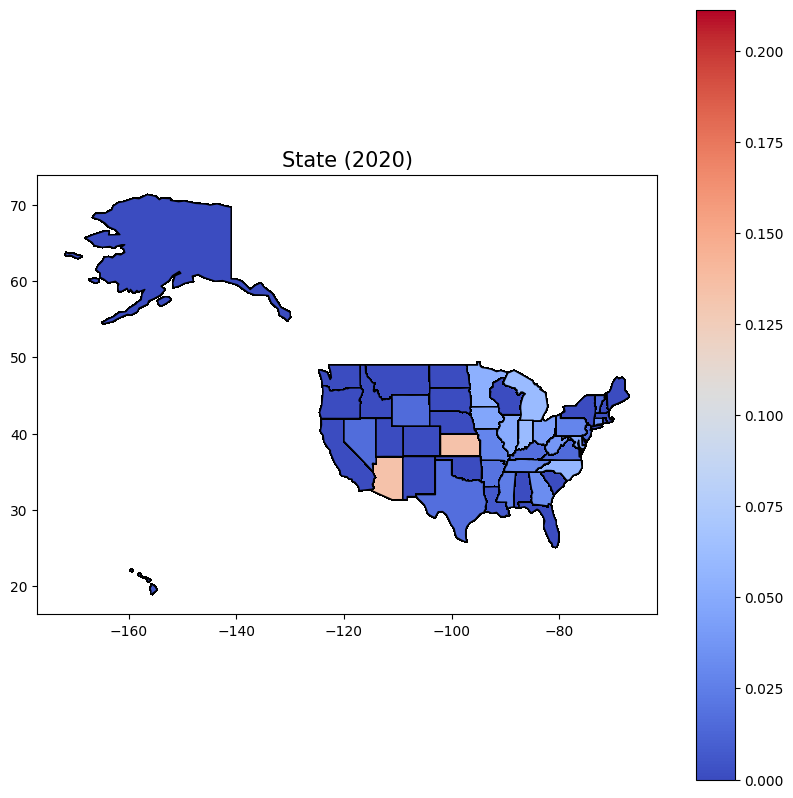

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

vmin = joined_data2020['cancel_rate_log'].quantile(0.05)
vmax = joined_data2020['cancel_rate_log'].quantile(0.95)

joined_data2020.plot(
    column='cancel_rate_log',
    ax=ax,
    cmap='coolwarm',
    legend=True,
    edgecolor='k',
    vmin=vmin,
    vmax=vmax
)

ax.set_title('State (2020)', fontsize=15)

plt.show()

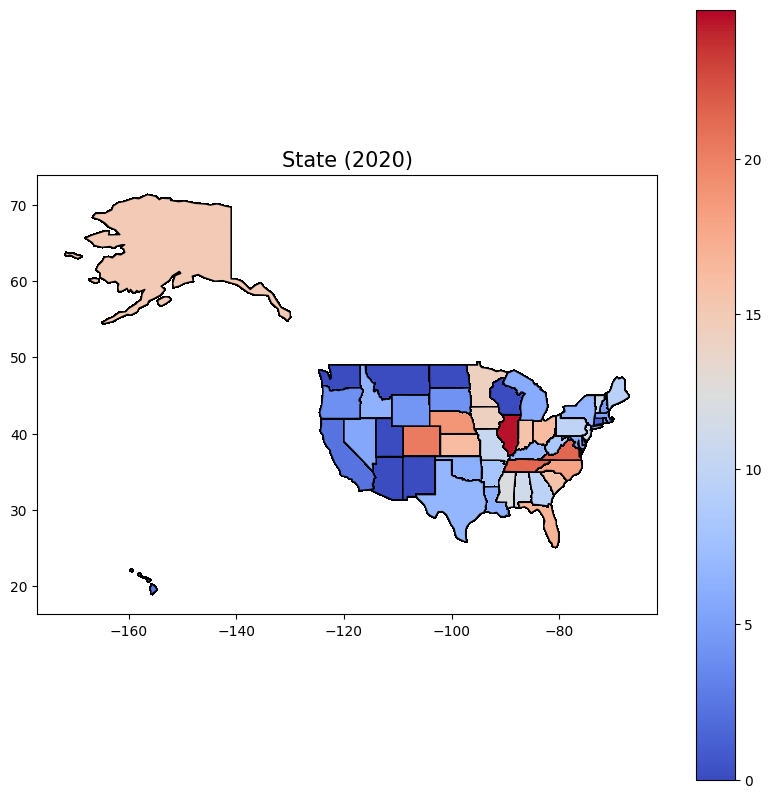

In [69]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

vmin = joined_data2020['arr_delay'].quantile(0.05)
vmax = joined_data2020['arr_delay'].quantile(0.95)

joined_data2020.plot(
    column='arr_delay',
    ax=ax,
    cmap='coolwarm',
    legend=True,
    edgecolor='k',
    vmin=vmin,
    vmax=vmax
)

ax.set_title('State (2020)', fontsize=15)

plt.show()

In [75]:
states_to_remove = ['Alaska', 'Hawaii']  # example

filtered = joined_data2020[
   ~joined_data2020['state'].isin(states_to_remove)
]

filtered.plot(
    column='arr_delay',
    ax=ax,
    cmap='coolwarm',
    legend=True,
    edgecolor='k',
    vmin=vmin,
    vmax=vmax
)

ax.set_title('State (2020)', fontsize=15)

plt.show()

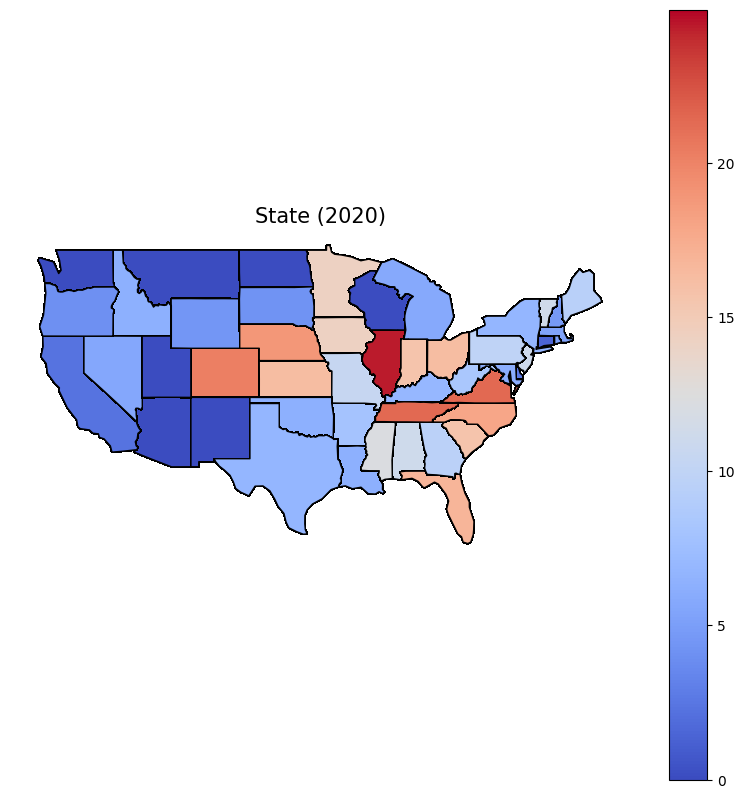

In [77]:
states_to_remove = ['US-AK', 'US-HI']

filtered = joined_data2020[
    ~joined_data2020['state'].isin(states_to_remove)
]

fig, ax = plt.subplots(figsize=(10, 10))

vmin = filtered['arr_delay'].quantile(0.05)
vmax = filtered['arr_delay'].quantile(0.95)

filtered.plot(
    column='arr_delay',
    ax=ax,
    cmap='coolwarm',
    legend=True,
    edgecolor='k',
    vmin=vmin,
    vmax=vmax
)

ax.set_title('State (2020)', fontsize=15)
ax.axis('off')

plt.show()

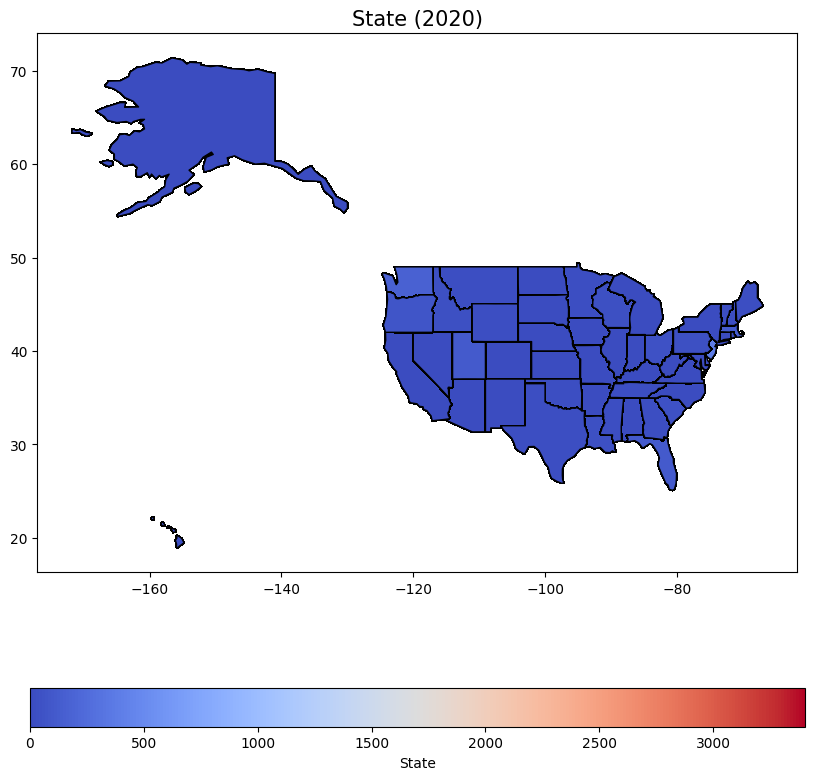

In [68]:
# Plot the map with GDP values
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot the geometry and color by GDP (USD)
plot_df.plot(column='arr_del15', ax=ax, legend=True,
                 legend_kwds={'label': "State",
                              'orientation': "horizontal"},
                 cmap='coolwarm', edgecolor='k')

# Add a title
ax.set_title('State (2020)', fontsize=15)

# Show the plot
plt.show()